# MScFE 600 Financial Data — Group Work Project 1
## Executable code: Part 1 (Step 3 replication) + Part 2 (social-media sentiment EDA)

**Student Group 16339** — Sidafa Conde, Lizzie Luhanga, Saurav Pal

This notebook accompanies the PDF report. It has two sections:

* **Section A — Part 1, Step 3:** replicate a slice of Sagaceta-Mejía et al. (2024) on the
  **iShares MSCI Chile ETF (ECH)**, using **Pearson correlation** as the feature-selection
  filter and **10-fold cross-validation** with a neural-network (MLP) classifier. We reproduce
  an accuracy-vs-number-of-features **table** and the supporting **graphs**, and we run a
  **robustness check** on the choice of prediction target.
* **Section B — Part 2:** import and explore a **social-media sentiment** sample.

> **How to submit:** In Google Colab choose *Runtime → Run all*, confirm every cell has output,
> then *File → Print → Save as PDF*. Zip this `.ipynb` together with that output PDF.

*Design note:* our primary target is the **next day's** Open direction, which keeps the setup
close to the paper. We show in Section A.9 why this target is optimistic and re-test the idea on
a cleaner Close-to-Close target.

### 0. Setup

In [1]:
# In Google Colab, uncomment to ensure dependencies:
# !pip -q install yfinance nltk

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
sns.set()
RANDOM_STATE = 42
TICKER = "ECH"

# Figures are saved next to the notebook, wherever it runs (Colab, Jupyter, etc.)
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

def savefig(name):
    try:
        plt.savefig(os.path.join(FIG_DIR, name), dpi=120, bbox_inches="tight")
    except Exception as e:
        print("(could not save figure:", e, ")")

print("Environment ready. Target fund:", TICKER)

Environment ready. Target fund: ECH


---
## Section A — Part 1, Step 3: Replication on ECH

### A.1 Download the data
We pull daily OHLCV for ECH from Yahoo Finance over the paper's pre-pandemic window
(2010-01-01 to 2020-01-01).

In [2]:
df = yf.download(TICKER, start="2010-01-01", end="2020-01-01",
                 auto_adjust=False, progress=False)
# Newer yfinance returns MultiIndex columns for a single ticker; flatten them.
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)
df = df.rename(columns=str)
df.to_csv("ECH.csv")  # cache alongside the notebook
print("Downloaded", df.shape[0], "trading days;", "columns:", list(df.columns))
df.head()

Downloaded 2516 trading days; columns: ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']


Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2010-01-04,37.070496,56.099998,56.299999,55.020000,55.570000,91800
2010-01-05,37.222485,56.330002,56.549999,56.099998,56.360001,122300
2010-01-06,37.823803,57.240002,57.330002,56.639999,56.770000,118500
2010-01-07,38.709263,58.580002,58.580002,57.150002,57.220001,653300
2010-01-08,39.237904,59.380001,59.450001,58.430000,58.700001,336000


### A.2 Price history
ECH adjusted-close price over the sample window.

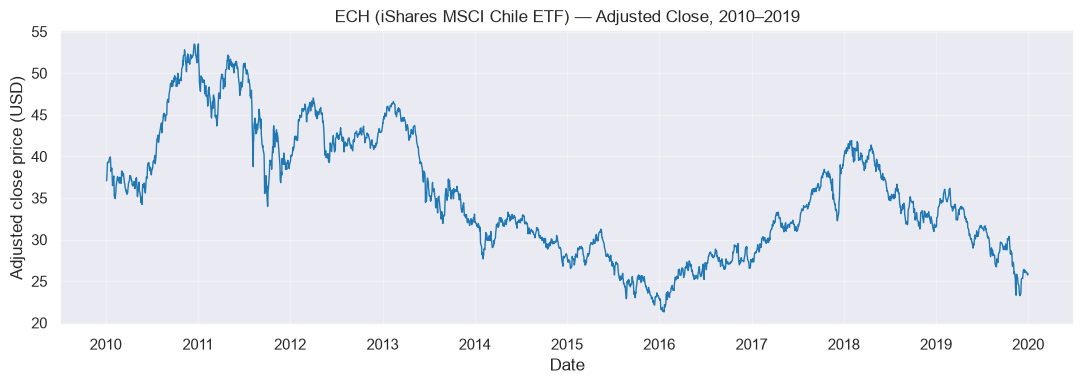

In [3]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(df.index, df["Adj Close"], color="tab:blue", lw=1)
ax.set_title("ECH (iShares MSCI Chile ETF) — Adjusted Close, 2010–2019")
ax.set_xlabel("Date")
ax.set_ylabel("Adjusted close price (USD)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
savefig("ech_price_history.png")
plt.show()

### A.3 Summary statistics
Descriptive statistics for the ECH price series, returns, and drawdown.

In [4]:
daily_ret = df["Adj Close"].pct_change()
summary = pd.DataFrame({
    "Open": df["Open"].describe(),
    "Close": df["Close"].describe(),
    "Adj Close": df["Adj Close"].describe(),
})
ann_vol = daily_ret.std() * np.sqrt(252)
cum_return = df["Adj Close"].iloc[-1] / df["Adj Close"].iloc[0] - 1
# Maximum drawdown: largest peak-to-trough decline on the adjusted-close path.
running_max = df["Adj Close"].cummax()
max_drawdown = (df["Adj Close"] / running_max - 1).min()
print("Annualized volatility: {:.1%}".format(ann_vol))
print("Cumulative return over window: {:.1%}".format(cum_return))
print("Maximum drawdown: {:.1%}".format(max_drawdown))
summary.round(2)

Annualized volatility: 20.8%
Cumulative return over window: -30.1%
Maximum drawdown: -60.2%


,Open,Close,Adj Close
count,2516.00,2516.00,2516.00
mean,50.07,50.06,35.30
std,12.25,12.26,7.44
min,29.30,29.62,21.32
25%,40.27,40.28,29.40
50%,46.39,46.40,33.96
75%,59.96,59.99,41.11
max,80.25,80.27,53.53


### A.4 Technical indicators (feature engineering)
The paper computes ~210 indicators with a technical-analysis library. To keep this notebook
portable (no fragile dependencies), we compute a **curated ~20-indicator** panel by hand,
spanning momentum, trend, volatility, and volume — the same families the paper's selected
features come from.

In [5]:
o, h, l, c, v = df["Open"], df["High"], df["Low"], df["Close"], df["Volume"]
feat = pd.DataFrame(index=df.index)

ret = c.pct_change()
delta = c.diff()

feat["ret"]      = ret                                   # daily return
feat["sma10"]    = c.rolling(10).mean() / c - 1.0        # price vs 10d SMA
feat["ema10"]    = c.ewm(span=10).mean() / c - 1.0       # price vs 10d EMA
feat["mom10"]    = c / c.shift(10) - 1.0                 # 10d momentum
feat["roc5"]     = c.pct_change(5)                       # 5d rate of change
feat["vol20"]    = ret.rolling(20).std()                 # 20d volatility

gain = delta.clip(lower=0).rolling(14).mean()
loss = (-delta.clip(upper=0)).rolling(14).mean()
feat["rsi14"]    = 100 - 100 / (1 + gain / loss.replace(0, np.nan))   # RSI

hh, ll = h.rolling(14).max(), l.rolling(14).min()
feat["willr14"]  = -100 * (hh - c) / (hh - ll)           # Williams %R
feat["stoch_k"]  = 100 * (c - ll) / (hh - ll)            # Stochastic %K
feat["stoch_d"]  = feat["stoch_k"].rolling(3).mean()     # Stochastic %D

feat["bop"]      = (c - o) / (h - l).replace(0, np.nan)  # Balance of Power
mb, sd = c.rolling(20).mean(), c.rolling(20).std()
feat["bbp"]      = (c - (mb - 2*sd)) / ((mb + 2*sd) - (mb - 2*sd))  # Bollinger Band %
feat["zscore30"] = (c - c.rolling(30).mean()) / c.rolling(30).std() # Z-score

obv = (np.sign(delta).fillna(0) * v).cumsum()
feat["obv_z"]    = (obv - obv.rolling(30).mean()) / obv.rolling(30).std()  # OBV (z-scored)

ema12, ema26 = c.ewm(span=12).mean(), c.ewm(span=26).mean()
macd = ema12 - ema26
feat["macd"]     = macd / c                              # MACD (scaled)
feat["macd_sig"] = macd.ewm(span=9).mean() / c           # MACD signal
feat["inc"]      = (delta > 0).astype(float)             # Increasing (Boolean)
feat["dec"]      = (delta < 0).astype(float)             # Decreasing (Boolean)
feat["hl_range"] = (h - l) / c                           # daily range
feat["vchg"]     = v.pct_change().replace([np.inf, -np.inf], np.nan)  # volume change
feat["cti12"]    = c.rolling(12).apply(                  # Correlation Trend Indicator
    lambda x: np.corrcoef(x, np.arange(len(x)))[0, 1], raw=True)

print("Engineered", feat.shape[1], "technical indicators")
feat.tail(3).round(3)

Engineered 21 technical indicators


,ret,sma10,ema10,mom10,roc5,vol20,rsi14,willr14,stoch_k,stoch_d,...,bbp,zscore30,obv_z,macd,macd_sig,inc,dec,hl_range,vchg,cti12
Date,,,,,,,,,,,,,,,,,,,,,
2019-12-27,-0.003,0.006,-0.001,-0.002,-0.004,0.013,65.141,-48.000,52.000,58.900,...,0.633,0.751,1.115,0.005,0.001,0.0,1.0,0.015,-0.290,-0.085
2019-12-30,-0.011,0.014,0.008,-0.025,-0.021,0.013,56.311,-68.571,31.429,47.990,...,0.538,0.420,0.856,0.004,0.002,0.0,1.0,0.015,1.662,-0.676
2019-12-31,0.007,0.005,0.001,-0.019,-0.004,0.013,60.615,-69.286,30.714,38.048,...,0.567,0.608,0.892,0.004,0.002,1.0,0.0,0.015,-0.644,-0.832


### A.5 Target label and preprocessing
The paper's class variable is the sign of the Open-price change. We predict the **next day's**
direction (`+1` up / `0` down) from today's indicators, then **min–max normalize** every
feature to [0, 1] and drop warm-up rows containing NaNs.

In [6]:
target = (o.shift(-1) - o > 0).astype(int)   # next-day Open direction

data = feat.copy()
data["y"] = target
data = data.replace([np.inf, -np.inf], np.nan).dropna()

y = data["y"]
X = data.drop(columns="y")
X = (X - X.min()) / (X.max() - X.min())      # min-max normalization

print("Samples:", X.shape[0], "| Features:", X.shape[1],
      "| Share of 'up' days: {:.1%}".format(y.mean()))

Samples: 2487 | Features: 21 | Share of 'up' days: 49.1%


### A.6 Feature selection by Pearson correlation
We rank each indicator by the **absolute Pearson correlation** with the target. This is the
"easier" filter metric (the paper also uses LASSO, Chi-squared, etc.).

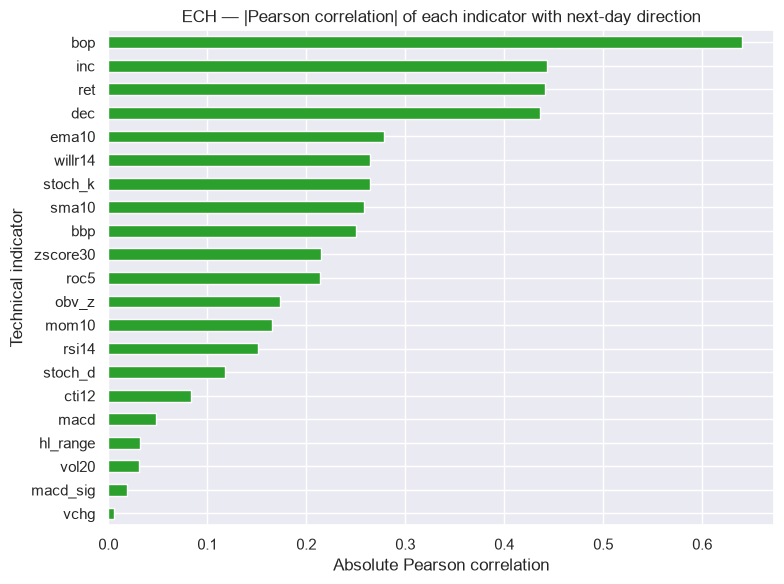

bop         0.640
inc         0.443
ret         0.441
dec         0.436
ema10       0.278
willr14     0.264
stoch_k     0.264
sma10       0.259
bbp         0.250
zscore30    0.215
roc5        0.214
obv_z       0.173
mom10       0.165
rsi14       0.151
stoch_d     0.117
cti12       0.083
macd        0.048
hl_range    0.032
vol20       0.031
macd_sig    0.018
vchg        0.005
dtype: float64

In [7]:
corr = X.apply(lambda col: np.corrcoef(col, y)[0, 1]).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
corr.sort_values().plot.barh(ax=ax, color="tab:green")
ax.set_title("ECH — |Pearson correlation| of each indicator with next-day direction")
ax.set_xlabel("Absolute Pearson correlation")
ax.set_ylabel("Technical indicator")
plt.tight_layout()
savefig("ech_feature_correlation.png")
plt.show()
corr.round(3)

### A.7 Cross-validated accuracy vs number of features
For increasing subset sizes `k` we take the top-`k` indicators by correlation, then score an
**MLP classifier** under **10-fold stratified cross-validation** (mirroring the paper's setup).
We report the **median** fold accuracy — the paper's analog of Table 4 — and compare against the
full feature set.

In [8]:
cv = StratifiedKFold(n_splits=10, shuffle=False)

def median_cv_accuracy(Xmat, yvec, columns):
    n_hidden = max(2, int((len(columns) + 2) / 2))
    clf = MLPClassifier(hidden_layer_sizes=(n_hidden,), activation="logistic",
                        solver="lbfgs", max_iter=5000, random_state=RANDOM_STATE)
    scores = cross_val_score(clf, Xmat[columns], yvec, cv=cv, scoring="accuracy")
    return np.median(scores)

ks = [2, 4, 6, 8, 10, 12, 15]
results = []
for k in ks:
    cols = list(corr.head(k).index)
    results.append({"n_features": k,
                    "median_accuracy_%": round(100*median_cv_accuracy(X, y, cols), 2)})

full_acc = round(100 * median_cv_accuracy(X, y, list(X.columns)), 2)
table = pd.DataFrame(results)
table.loc[len(table)] = {"n_features": X.shape[1], "median_accuracy_%": full_acc}
table = table.rename(columns={"n_features": "Number of features",
                              "median_accuracy_%": "Median CV accuracy (%)"})
print("Full-set ({} features) median accuracy: {:.2f}%".format(X.shape[1], full_acc))
table.reset_index(drop=True)

Full-set (21 features) median accuracy: 74.70%


,Number of features,Median CV accuracy (%)
0,2,80.12
1,4,79.72
2,6,79.68
3,8,79.72
4,10,78.92
5,12,78.51
6,15,76.71
7,21,74.70


### A.8 Accuracy-vs-features curve
Visual analog of the paper's feature-selection gain plot.

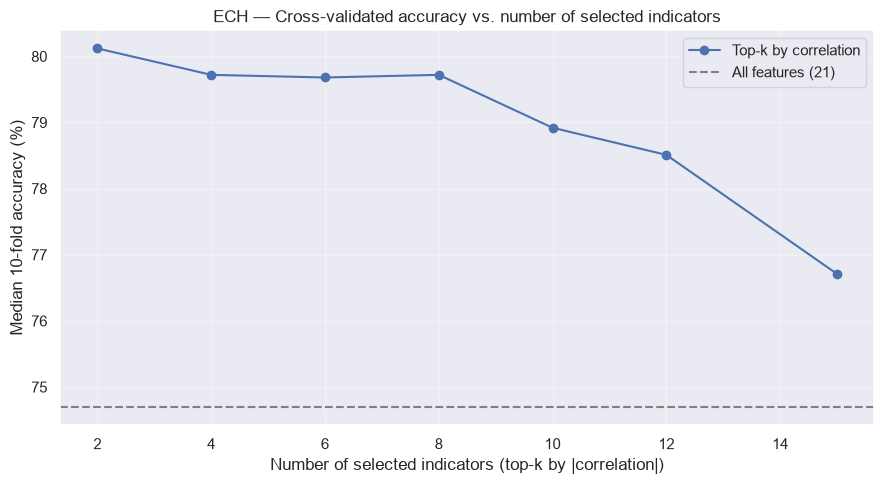

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
sub = table.iloc[:-1]
ax.plot(sub["Number of features"], sub["Median CV accuracy (%)"],
        marker="o", label="Top-k by correlation")
ax.axhline(full_acc, color="grey", ls="--", label="All features ({})".format(X.shape[1]))
ax.set_title("ECH — Cross-validated accuracy vs. number of selected indicators")
ax.set_xlabel("Number of selected indicators (top-k by |correlation|)")
ax.set_ylabel("Median 10-fold accuracy (%)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
savefig("ech_accuracy_vs_features.png")
plt.show()

### A.9 Robustness check — is the accuracy real, or a feature of the target?
Our next-day **Open** target has a hidden trap. The next Open is very close to today's Close, so
any indicator built from `Close − Open` (Balance of Power, the Increasing/Decreasing flags, the
daily return) nearly **encodes** the label instead of forecasting it. That mechanical link, not
genuine skill, is the likeliest reason a two-indicator model reaches ~80%.

To test this, we re-run the identical pipeline on a cleaner target: the next-day **Close-to-Close**
direction, which cannot be read off from today's close-minus-open. If the earlier accuracy was an
artifact, it should collapse toward the ~50% no-skill line here.

In [10]:
# Cleaner target: next-day Close-to-Close direction (features still known at time t).
target_cc = (c.shift(-1) - c > 0).astype(int)
data_cc = feat.copy()
data_cc["y"] = target_cc
data_cc = data_cc.replace([np.inf, -np.inf], np.nan).dropna()
y_cc = data_cc["y"]
X_cc = data_cc.drop(columns="y")
X_cc = (X_cc - X_cc.min()) / (X_cc.max() - X_cc.min())
corr_cc = X_cc.apply(lambda col: np.corrcoef(col, y_cc)[0, 1]).abs().sort_values(ascending=False)

rows = []
for k in [2, 4, 6, 8, 10]:
    cols_open = list(corr.head(k).index)
    cols_cc = list(corr_cc.head(k).index)
    rows.append({
        "Number of features": k,
        "Open-to-Open acc. (%)": round(100*median_cv_accuracy(X, y, cols_open), 2),
        "Close-to-Close acc. (%)": round(100*median_cv_accuracy(X_cc, y_cc, cols_cc), 2),
    })
robust = pd.DataFrame(rows)
print("Share of up days — Close-to-Close: {:.1%}".format(y_cc.mean()))
robust

Share of up days — Close-to-Close: 49.3%


,Number of features,Open-to-Open acc. (%),Close-to-Close acc. (%)
0,2,80.12,54.22
1,4,79.72,53.61
2,6,79.68,53.72
3,8,79.72,53.01
4,10,78.92,52.71


**Reading the robustness check (for the report, in your own words).** The Open-to-Open
accuracy is high, but on the cleaner Close-to-Close target the accuracy falls close to the ~50%
no-skill line. This confirms that the headline accuracy is driven mainly by the overnight-gap
link between today's close and tomorrow's open, not by real predictive power. The paper's central
*idea* — a small selected indicator set can match a larger one — still holds, but the level of
accuracy should be read with this caveat. Report the exact numbers **from your own run**.

---
## Section B — Part 2: Social-media sentiment EDA
We load a small, reproducible sample of finance social-media posts, derive sentiment with a
lexicon model (VADER), aggregate to a daily series, and explore it. *In production you would load
a full dataset (e.g. a StockTwits/Twitter research corpus) — see the Part 2 user guide.*

In [11]:
# Small illustrative sample (reproducible; replace with a real corpus for production use).
sample = pd.DataFrame({
    "timestamp": pd.to_datetime([
        "2020-06-01","2020-06-01","2020-06-01","2020-06-02","2020-06-02","2020-06-03",
        "2020-06-03","2020-06-03","2020-06-04","2020-06-04","2020-06-05","2020-06-05",
        "2020-06-05","2020-06-08","2020-06-08","2020-06-09","2020-06-09","2020-06-10",
        "2020-06-10","2020-06-11","2020-06-11","2020-06-12","2020-06-12","2020-06-12"]),
    "ticker": ["SPY"]*24,
    "text": [
        "SPY looking strong, breakout incoming to the moon!",
        "Bearish on $SPY, this rally makes no sense, selling",
        "Holding my calls, bulls in control today",
        "Market crashing again, I'm scared, dumping everything",
        "Great earnings, $SPY to new highs, very bullish",
        "This dip is a gift, buying more SPY",
        "Ugh red day, bears winning, puts printing",
        "Neutral here, waiting for a clearer signal",
        "Massive rally, best day ever for my portfolio",
        "Overbought, expecting a pullback soon, cautious",
        "SPY green again, uptrend intact, loving it",
        "Fed comments spooked the market, selloff hard",
        "Buying the fear, long term bullish on stocks",
        "Choppy action, no conviction either way",
        "Breaking resistance, momentum is bullish",
        "Terrible price action, bearish reversal likely",
        "Adding to my position, confident in the trend",
        "Panic selling everywhere, ugly candles",
        "Recovery underway, dip buyers stepping in",
        "New all time highs, euphoria is real, bullish",
        "Taking profits, market feels toppy and risky",
        "Sideways grind continues, boring session",
        "Strong close, bulls defended support nicely",
        "Worried about a correction, hedging my longs"],
})
sample["date"] = sample["timestamp"].dt.date
print("Loaded", len(sample), "sample posts")
sample.head()

Loaded 24 sample posts


,timestamp,ticker,text,date
0,2020-06-01,SPY,"SPY looking strong, breakout incoming to the m...",2020-06-01
1,2020-06-01,SPY,"Bearish on $SPY, this rally makes no sense, se...",2020-06-01
2,2020-06-01,SPY,"Holding my calls, bulls in control today",2020-06-01
3,2020-06-02,SPY,"Market crashing again, I'm scared, dumping eve...",2020-06-02
4,2020-06-02,SPY,"Great earnings, $SPY to new highs, very bullish",2020-06-02


In [12]:
# Derive sentiment with VADER (falls back to a tiny keyword model if offline).
try:
    import nltk
    nltk.download("vader_lexicon", quiet=True)
    from nltk.sentiment import SentimentIntensityAnalyzer
    sia = SentimentIntensityAnalyzer()
    sample["compound"] = sample["text"].apply(lambda t: sia.polarity_scores(t)["compound"])
    print("Sentiment via VADER")
except Exception as e:
    print("VADER unavailable (", e, ") — using keyword fallback")
    bull = ["bull","moon","strong","buy","green","rally","highs","up","confident","recovery"]
    bear = ["bear","crash","sell","red","dump","puts","panic","fear","correction","toppy"]
    def kw(t):
        t = t.lower(); return (sum(w in t for w in bull) - sum(w in t for w in bear)) / 5.0
    sample["compound"] = sample["text"].apply(kw).clip(-1, 1)

sample["label"] = np.where(sample["compound"] > 0.05, "Bullish",
                    np.where(sample["compound"] < -0.05, "Bearish", "Neutral"))
sample[["date","text","compound","label"]].head()

Sentiment via VADER


,date,text,compound,label
0,2020-06-01,"SPY looking strong, breakout incoming to the m...",0.5562,Bullish
1,2020-06-01,"Bearish on $SPY, this rally makes no sense, se...",-0.2960,Bearish
2,2020-06-01,"Holding my calls, bulls in control today",0.0000,Neutral
3,2020-06-02,"Market crashing again, I'm scared, dumping eve...",-0.6369,Bearish
4,2020-06-02,"Great earnings, $SPY to new highs, very bullish",0.6249,Bullish


In [13]:
# Aggregate to a daily sentiment + message-volume series
daily = (sample.groupby("date")
               .agg(msg_volume=("text", "size"), mean_sentiment=("compound", "mean"))
               .reset_index())
daily["date"] = pd.to_datetime(daily["date"])
daily

,date,msg_volume,mean_sentiment
0,2020-06-01,3,0.086733
1,2020-06-02,2,-0.006000
2,2020-06-03,3,0.197833
3,2020-06-04,2,0.267100
4,2020-06-05,3,0.031400
5,2020-06-08,2,-0.148000
6,2020-06-09,2,0.008600
7,2020-06-10,2,-0.382500
8,2020-06-11,2,0.460900
9,2020-06-12,3,0.073933


### B.1 EDA plots

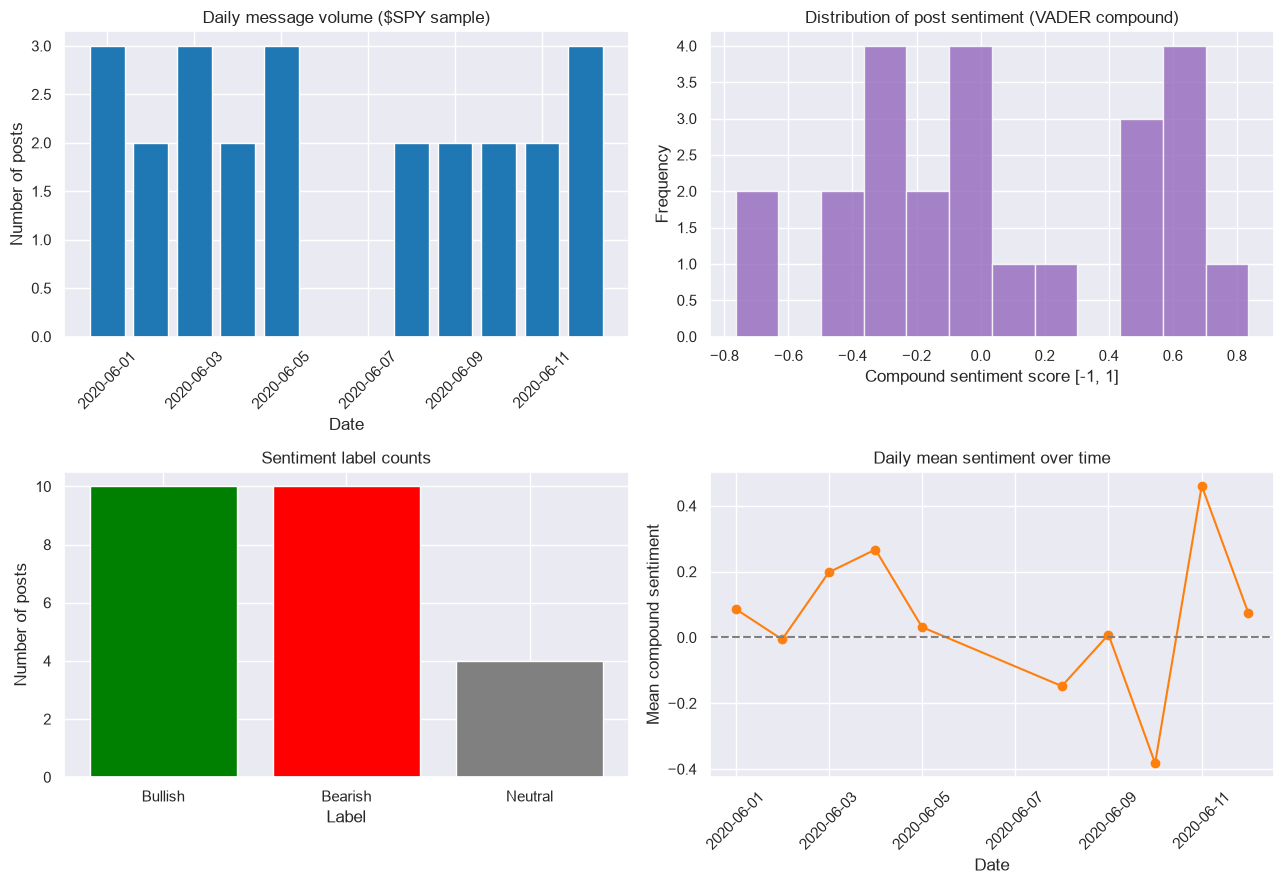

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (1) message volume over time
axes[0,0].bar(daily["date"], daily["msg_volume"], color="tab:blue")
axes[0,0].set_title("Daily message volume ($SPY sample)")
axes[0,0].set_xlabel("Date"); axes[0,0].set_ylabel("Number of posts")
axes[0,0].tick_params(axis="x", rotation=45)

# (2) sentiment distribution
axes[0,1].hist(sample["compound"], bins=12, color="tab:purple", alpha=0.8)
axes[0,1].set_title("Distribution of post sentiment (VADER compound)")
axes[0,1].set_xlabel("Compound sentiment score [-1, 1]"); axes[0,1].set_ylabel("Frequency")

# (3) bull/bear/neutral balance
counts = sample["label"].value_counts()
axes[1,0].bar(counts.index, counts.values, color=["green","red","grey"])
axes[1,0].set_title("Sentiment label counts")
axes[1,0].set_xlabel("Label"); axes[1,0].set_ylabel("Number of posts")

# (4) daily mean sentiment over time
axes[1,1].plot(daily["date"], daily["mean_sentiment"], marker="o", color="tab:orange")
axes[1,1].axhline(0, color="grey", ls="--")
axes[1,1].set_title("Daily mean sentiment over time")
axes[1,1].set_xlabel("Date"); axes[1,1].set_ylabel("Mean compound sentiment")
axes[1,1].tick_params(axis="x", rotation=45)

plt.tight_layout()
savefig("sentiment_eda.png")
plt.show()

**Reading the results (for the report, in your own words).** Describe the sentiment
distribution (balance of bullish vs bearish), how message volume moves day to day, and — with a
*real* dataset — whether daily sentiment shows any lead/lag relationship with returns. Emphasize
that social sentiment is a **weak, noisy** signal, most useful as an attention/volume proxy.

---
### References
* Sagaceta-Mejía, A. R., Sánchez-Gutiérrez, M. E., & Fresán-Figueroa, J. A. (2024).
  *An Intelligent Approach for Predicting Stock Market Movements in Emerging Markets Using
  Optimized Technical Indicators and Neural Networks.* Economics, 18(1).
* Sun, Y., et al. (2024). *Alternative Data in Finance and Business: Emerging Applications and
  Theory Analysis (Review).* Financial Innovation, 10.

*See `report/references.md` for the full MLA bibliography.*